# 02 — Paired-Feature Visualization (M1 output)

**Pipeline stage:** visual inspection of the time-aligned `[audio | OEP]` matrices produced by
Milestone&nbsp;1 (M1).

**Scripts this notebook replaces / demonstrates**
| Script | What it does |
|--------|--------------|
| `scripts/plot_paired_features.py` | interactive single-file PDF plots |
| `scripts/batch_plot_paired.py` | batch PDF generation for a whole cohort |
| `pneumophonic_analysis/visualization.py` (`Visualizer`) | the reusable plotting class |

Each paired HDF5 file holds one subject × task recording: per-frame audio features
(`f0`, `energy`, `spectral_centroid`, `mfcc_0..12`), per-frame OEP respiratory features
(`vcw`, `vrc`, `vab`, `flow_*`, `pct_rc`, `pct_ab`, `delta_*`), **and** the full
STFT / mel / MFCC matrices used to build them.

> **Plot types demonstrated here:** dual-axis line (energy vs volume, F0 vs flow),
> compartmental line plot, correlation heatmap, STFT spectrogram, mel-spectrogram,
> MFCC heatmap, F0 trace (with mean±SD band), and chest-wall volume with FRC zones.

## 0. Setup
Locate the repository, import the package, and find the paired HDF5 corpus.

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# Make the repo importable no matter where Jupyter was launched from
REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

from pneumophonic_analysis.paired_features import PairedFeatureExtractor
from pneumophonic_analysis.visualization import Visualizer

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
assert PAIRED_DIR.exists(), f"No paired/ dir at {PAIRED_DIR} — run scripts/batch_extract.py first."
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
print(f"Found {len(h5_files)} paired HDF5 files in {PAIRED_DIR.relative_to(REPO)}")

Found 546 paired HDF5 files in data_target\healthy_subjects\paired


## 1. Load one example recording
We use a sustained-phonation task (`a_2`, maximum phonation time on /a/) because the FRC crossing is well defined for single-breath phonation.

In [2]:

def pick(task_suffix):
    # Return the first available HDF5 file whose task matches.
    for f in h5_files:
        if f.stem.endswith(task_suffix):
            return f
    return h5_files[0]

H5 = pick("_a_2")
df, meta = PairedFeatureExtractor.load_hdf5(H5)
SID, TASK = meta["subject_id"], meta["task_name"]

print(f"Example file : {H5.name}")
print(f"Subject/Task : {SID} / {TASK}")
print(f"Aligned matrix: {df.shape[0]} frames x {df.shape[1]} features")
print(f"Duration     : {df['time'].iloc[-1]:.2f} s")

# Two-compartment sanity check: Vrc + Vab should equal Vcw
err = (df['vrc'] + df['vab'] - df['vcw']).abs().mean()
print(f"Compartmental check |Vrc + Vab - Vcw| = {err:.2e} L  ->  {'OK' if err < 1e-2 else 'CHECK MAPPING'}")
df.head(3)

Example file : AlMo_a_2.h5
Subject/Task : AlMo / a_2
Aligned matrix: 1182 frames x 33 features
Duration     : 17.71 s
Compartmental check |Vrc + Vab - Vcw| = 3.27e-07 L  ->  OK


,delta_vab,delta_vcw,delta_vrc,energy,f0,f0_raw,flow_ab,flow_cw,flow_rc,mfcc_0,...,pct_rc,spectral_centroid,time,vab,vcw,voiced,voicing_prob,vrc,vrca,vrcp
0,0.000000,0.000000,0.000000,0.000001,NaN,NaN,0.485879,1.251091,0.765212,-3.223023,...,0.707510,330.236477,0.000,6.753103,23.088282,0.0,0.01,16.335179,4.203308,12.131871
1,0.007181,0.021119,0.013938,0.000004,NaN,NaN,0.503393,1.259219,0.755826,-2.920738,...,0.707466,207.667063,0.015,6.760284,23.109401,0.0,0.01,16.349117,4.207745,12.141372
2,0.015468,0.041244,0.025776,0.000002,NaN,NaN,0.529729,1.265719,0.735992,-2.946052,...,0.707362,249.554554,0.030,6.768571,23.129526,0.0,0.01,16.360955,4.211485,12.149470


## 2. Audio energy vs chest-wall volume
The first diagnostic plot in `plot_paired_features.py`: acoustic energy (loudness proxy) on the
left axis, the volume excursion `ΔVcw` (litres relative to onset) on the right. During sustained
phonation the chest wall deflates monotonically while energy stays roughly constant.

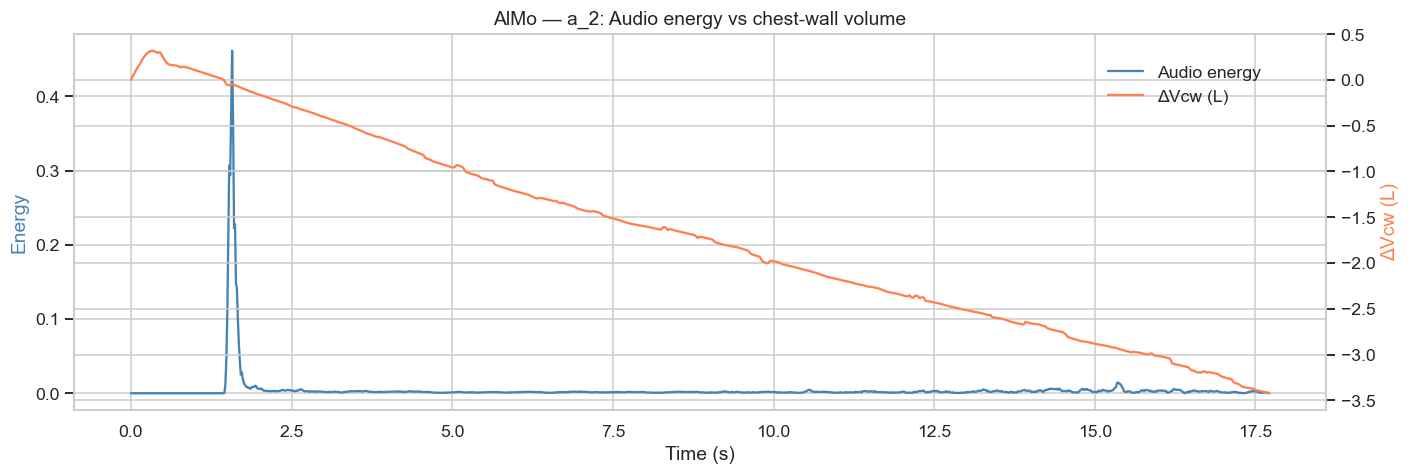

In [3]:

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(df['time'], df['energy'], color='steelblue', label='Audio energy')
ax1.set_ylabel('Energy', color='steelblue'); ax1.set_xlabel('Time (s)')
ax2 = ax1.twinx()
ax2.plot(df['time'], df['delta_vcw'], color='coral', label='ΔVcw (L)')
ax2.set_ylabel('ΔVcw (L)', color='coral')
ax1.set_title(f"{SID} — {TASK}: Audio energy vs chest-wall volume")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()

## 3. F0 vs expiratory flow (voiced frames only)
Fundamental frequency against chest-wall flow `flow_cw`. Restricting to voiced frames removes the
unvoiced gaps where F0 is undefined.

Voiced frames: 993 / 1182 (84.0%)


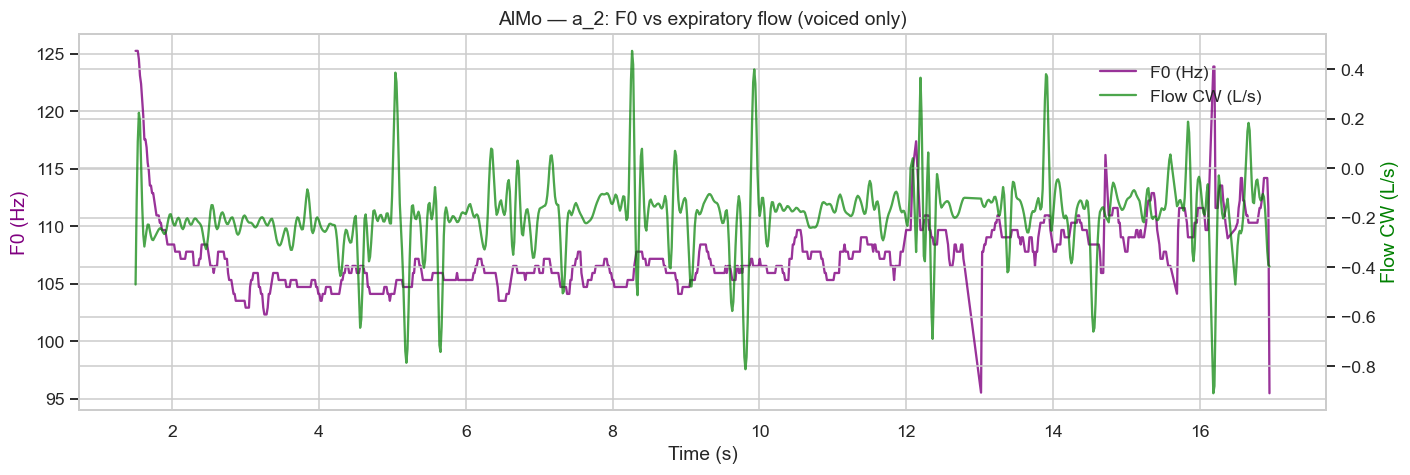

In [4]:

voiced = df[df['voiced'] == 1.0].copy()
print(f"Voiced frames: {len(voiced)} / {len(df)} ({len(voiced)/len(df)*100:.1f}%)")

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(voiced['time'], voiced['f0'], color='purple', alpha=0.8, label='F0 (Hz)')
ax1.set_ylabel('F0 (Hz)', color='purple'); ax1.set_xlabel('Time (s)')
ax2 = ax1.twinx()
ax2.plot(voiced['time'], voiced['flow_cw'], color='green', alpha=0.7, label='Flow CW (L/s)')
ax2.set_ylabel('Flow CW (L/s)', color='green')
ax1.set_title(f"{SID} — {TASK}: F0 vs expiratory flow (voiced only)")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()

## 4. Compartmental strategy over time
Instantaneous contribution of the rib cage (`pct_rc`) and abdomen (`pct_ab`) to total chest-wall
volume. Their split is the breathing *strategy* — rib-cage- vs abdomen-dominant phonation.

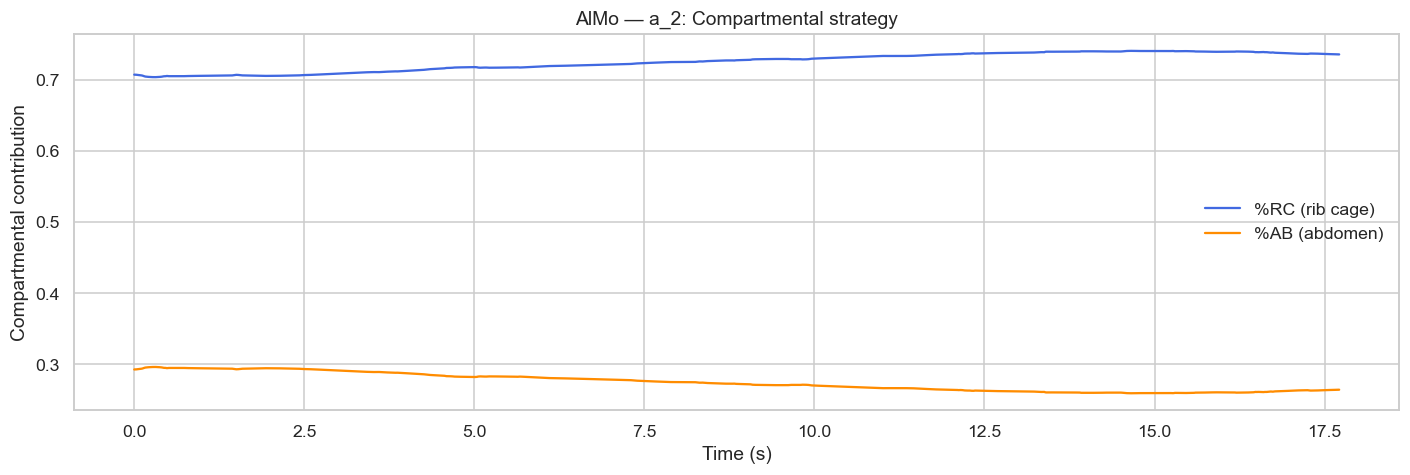

In [5]:

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df['time'], df['pct_rc'], color='royalblue', label='%RC (rib cage)')
ax.plot(df['time'], df['pct_ab'], color='darkorange', label='%AB (abdomen)')
ax.set_ylabel('Compartmental contribution'); ax.set_xlabel('Time (s)')
ax.set_title(f"{SID} — {TASK}: Compartmental strategy")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Within-recording correlation matrix
Pearson correlations between the main audio and OEP features on voiced frames — the per-segment
building block of the M2 analysis (notebook&nbsp;03).

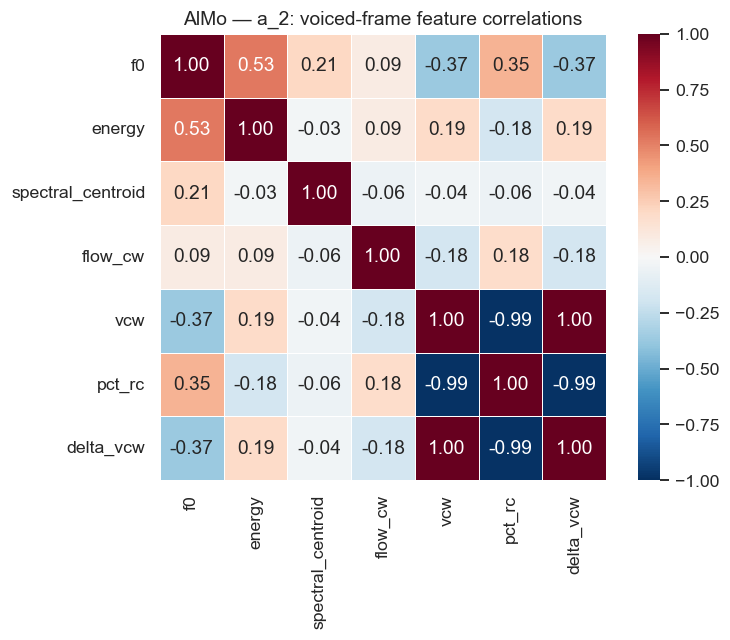

In [6]:

cols = ['f0', 'energy', 'spectral_centroid', 'flow_cw', 'vcw', 'pct_rc', 'delta_vcw']
corr = voiced[cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title(f"{SID} — {TASK}: voiced-frame feature correlations")
plt.tight_layout(); plt.show()

## 6. Spectral representations stored in the HDF5
`PairedFeatureExtractor.save_hdf5` also persists the full **STFT power spectrogram**, the
**mel-spectrogram**, and the **MFCC** matrix, so the raw `.wav` is not needed to inspect the
time–frequency content. We read them directly with `h5py`.

In [7]:

with h5py.File(H5, 'r') as f:
    S_power = f['stft'][:]    # (n_freq, n_frames) power spectrogram
    M_power = f['mel'][:]     # (n_mels, n_frames)
    MFCC    = f['mfcc'][:]    # (13, n_frames)
SR  = int(meta['sr_audio']); HOP = int(meta['hop_length'])
print(f"stft {S_power.shape} | mel {M_power.shape} | mfcc {MFCC.shape}  (sr={SR}, hop={HOP})")

stft (721, 1182) | mel (64, 1182) | mfcc (13, 1662)  (sr=48000, hop=720)


### 6a. STFT spectrogram (log-frequency)

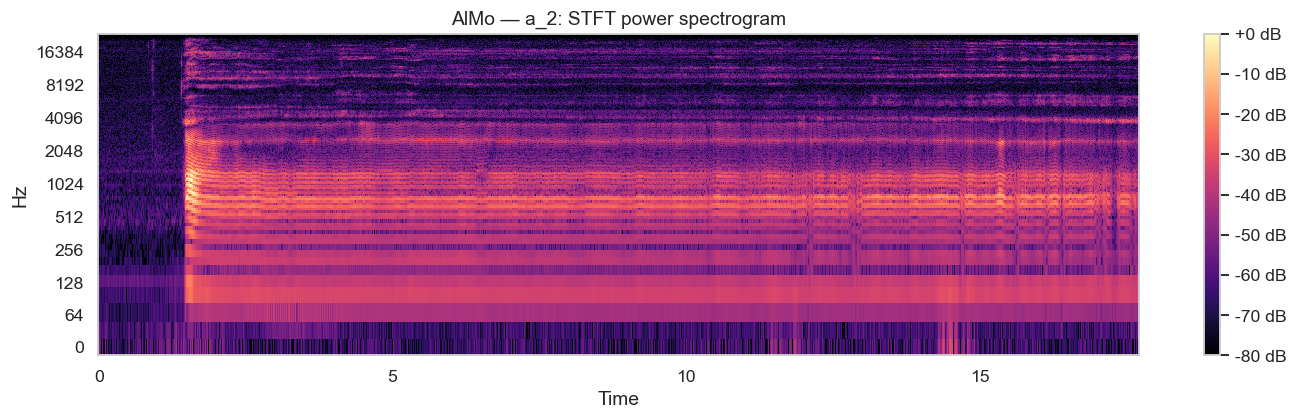

In [8]:

S_db = librosa.power_to_db(S_power, ref=np.max)
fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(S_db, sr=SR, hop_length=HOP, x_axis='time', y_axis='log',
                               ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title(f"{SID} — {TASK}: STFT power spectrogram")
plt.tight_layout(); plt.show()

### 6b. Mel-spectrogram

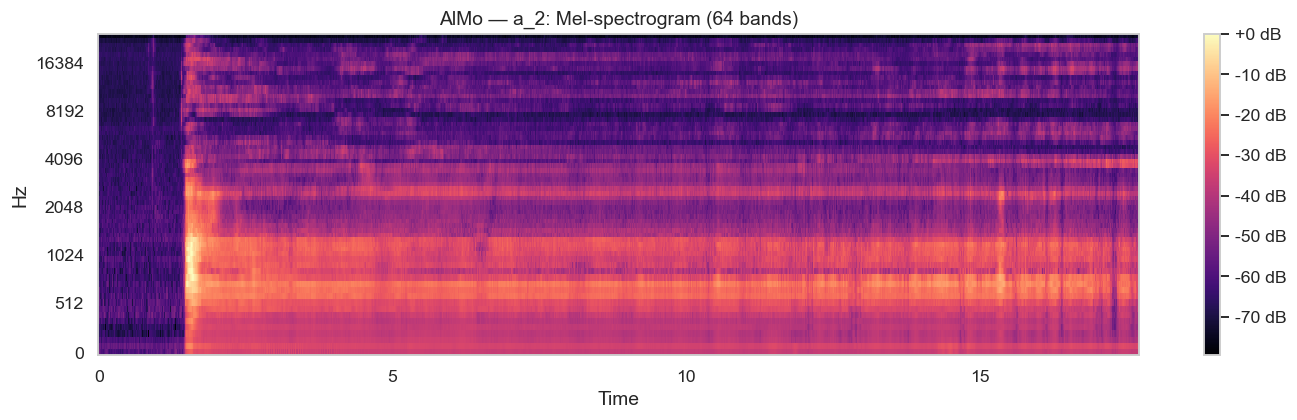

In [9]:

M_db = librosa.power_to_db(M_power, ref=np.max)
fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(M_db, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel',
                               ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title(f"{SID} — {TASK}: Mel-spectrogram (64 bands)")
plt.tight_layout(); plt.show()

### 6c. MFCC heatmap
13 mel-frequency cepstral coefficients over time (z-normalised per coefficient).

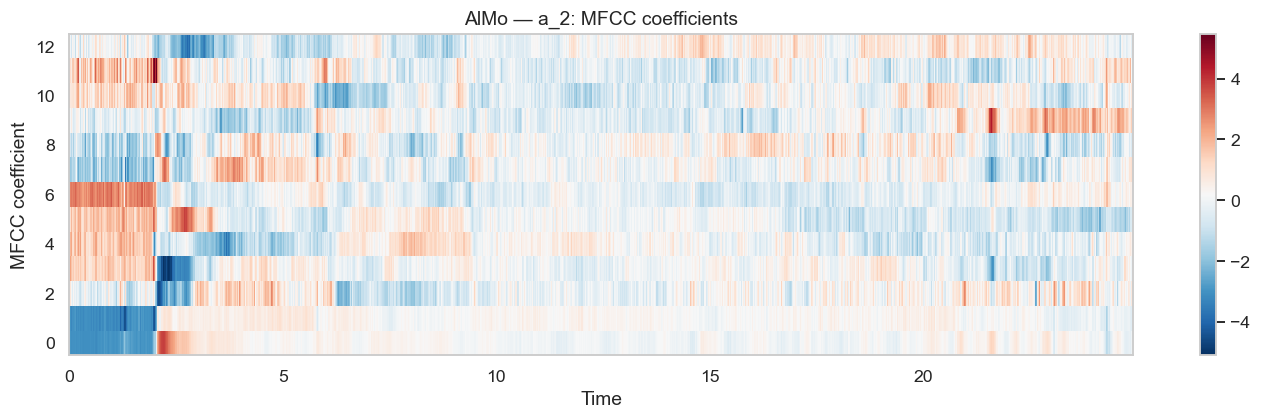

In [10]:

fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(MFCC, sr=SR, hop_length=HOP, x_axis='time', ax=ax, cmap='RdBu_r')
fig.colorbar(img, ax=ax)
ax.set_ylabel('MFCC coefficient'); ax.set_yticks(range(0, 13, 2))
ax.set_title(f"{SID} — {TASK}: MFCC coefficients")
plt.tight_layout(); plt.show()

## 7. Reusing the package `Visualizer`
The two plots below come straight from `pneumophonic_analysis.visualization.Visualizer`, the class
used across the legacy pipeline. First the **F0 trace** with its mean ± 1 SD band.

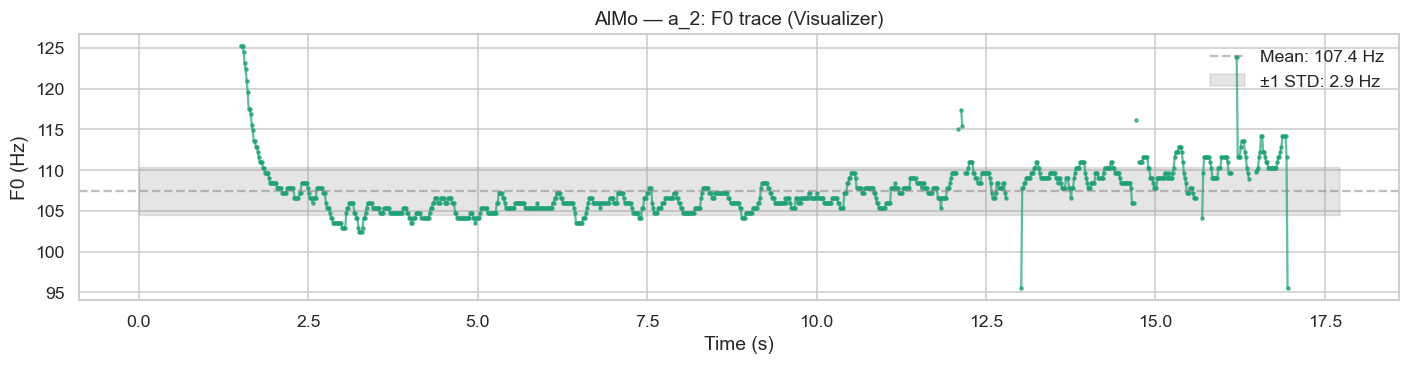

In [11]:

viz = Visualizer()
f0_frame_rate = 1.0 / (df['time'].iloc[1] - df['time'].iloc[0])   # ~66.7 fps
hop_equiv = int(round(SR / f0_frame_rate))
fig = viz.plot_f0_trace(df['f0'].values, hop_length=hop_equiv, sr=SR,
                        title=f"{SID} — {TASK}: F0 trace (Visualizer)")
fig.set_size_inches(13, 3.5)
plt.tight_layout(); plt.show()

### 7b. Chest-wall volume with FRC zones
`Visualizer.plot_oep_volume` shades the recording into **above-FRC** (elastic recoil) and
**below-FRC** (active expiratory effort) regions. We locate the FRC crossing with the same
peak-then-descent detector used by the L3 / FRC analyses (notebook&nbsp;04).

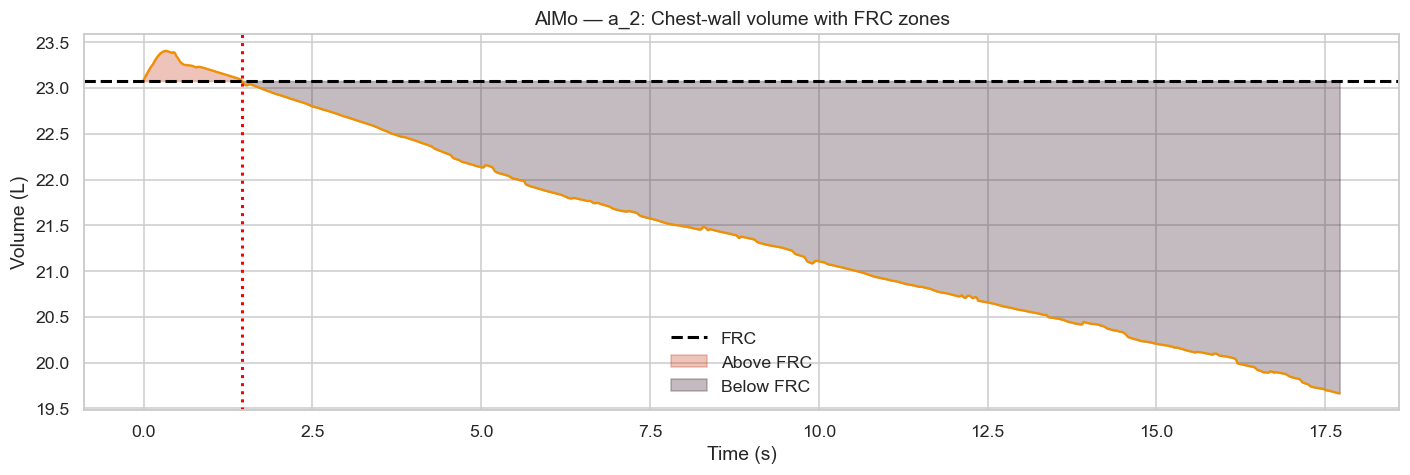

FRC crossing at frame 97 (t = 1.46s), FRC level = 23.077 L


In [12]:

from analyze_l3_stratified import find_frc_crossing_index

vcw = df['vcw'].values
cross = find_frc_crossing_index(df['delta_vcw'].values)
frc_level = float(vcw[cross]) if cross is not None else float(np.median(vcw))

fig = viz.plot_oep_volume(vcw, fs_oep=f0_frame_rate, frc_level=frc_level,
                          frc_cross_sample=cross,
                          title=f"{SID} — {TASK}: Chest-wall volume with FRC zones")
fig.set_size_inches(13, 4.5)
plt.tight_layout(); plt.show()
print(f"FRC crossing at frame {cross} (t = {df['time'].iloc[cross]:.2f}s), FRC level = {frc_level:.3f} L")

## Recap
From a single paired HDF5 file we reproduced every per-recording plot the M1 visualization scripts
produce, plus the stored time–frequency representations — **no raw audio required**. The next
notebook (03) aggregates these recordings across the whole cohort for the M2 correlation study.